In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add project root to path to access the src module
sys.path.append(os.path.abspath('..'))

from src.data_loader import DataLoader

# Visual settings for scientific publication standards
sns.set_context("paper", font_scale=1.4)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14

print("✅ Environment Ready. Starting Analysis...")

✅ Environment Ready. Starting Analysis...


In [2]:
loader = DataLoader(raw_data_path="../data/raw/airfoil_self_noise.csv")
df = loader.load_raw_data()
df = loader.validate_physics(df)

print(f"\nDataset Summary:\n- Total Samples: {df.shape[0]}\n- Feature Count: {df.shape[1]}")
display(df.describe().T) # Statistical summary table

[INFO] Raw data loaded successfully. Shape: (1503, 6)

--- Starting Aerodynamic Physics Validation ---
[PASS] Frequency and Velocity values are valid (non-negative).
[PASS] Sound Pressure Levels are within a realistic range.
[PASS] Geometric features (Chord Length) are valid.
--- Physics Validation Completed ---


Dataset Summary:
- Total Samples: 1503
- Feature Count: 6


,count,mean,std,min,25%,50%,75%,max
Frequency,1503.0,2886.380572,3152.573137,200.000000,800.000000,1600.000000,4000.000000,20000.000000
Angle_of_Attack,1503.0,6.782302,5.918128,0.000000,2.000000,5.400000,9.900000,22.200000
Chord_Length,1503.0,0.136548,0.093541,0.025400,0.050800,0.101600,0.228600,0.304800
Free_Stream_Velocity,1503.0,50.860745,15.572784,31.700000,39.600000,39.600000,71.300000,71.300000
Suction_Side_Displacement_Thickness,1503.0,0.011140,0.013150,0.000401,0.002535,0.004957,0.015576,0.058411
Sound_Pressure_Level,1503.0,124.835943,6.898657,103.380000,120.191000,125.721000,129.995500,140.987000


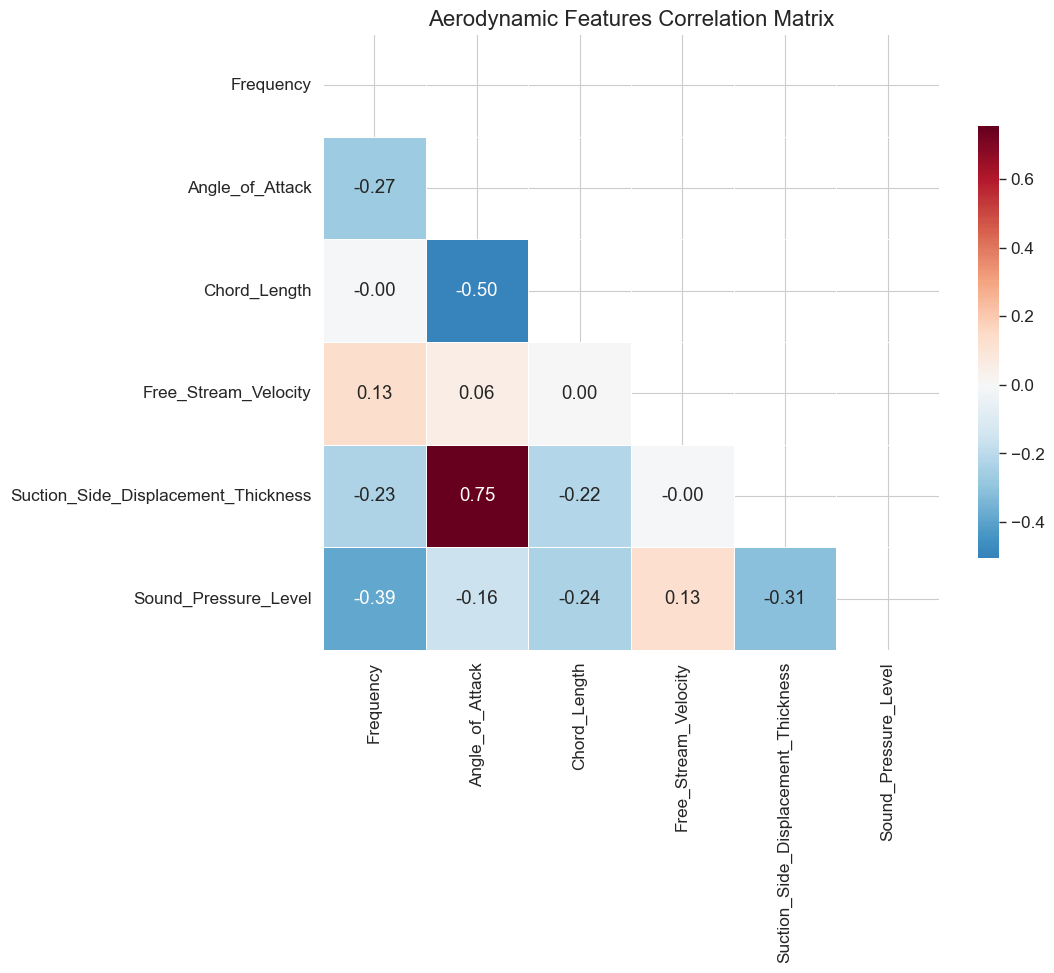


📝 **Paper Note:** - There is a strong negative correlation (-0.39) between Frequency and Sound Pressure. As frequency increases, energy dissipates.
- There is a positive relationship between Suction Side Displacement Thickness and noise. Thicker boundary layers imply more turbulence, thus more noise.



In [3]:
# Which aerodynamic feature affects noise the most?
plt.figure(figsize=(10, 8))
corr = df.corr()

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, 
            fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title("Aerodynamic Features Correlation Matrix")
plt.show()

print("""
📝 **Paper Note:** - There is a strong negative correlation (-0.39) between Frequency and Sound Pressure. As frequency increases, energy dissipates.
- There is a positive relationship between Suction Side Displacement Thickness and noise. Thicker boundary layers imply more turbulence, thus more noise.
""")

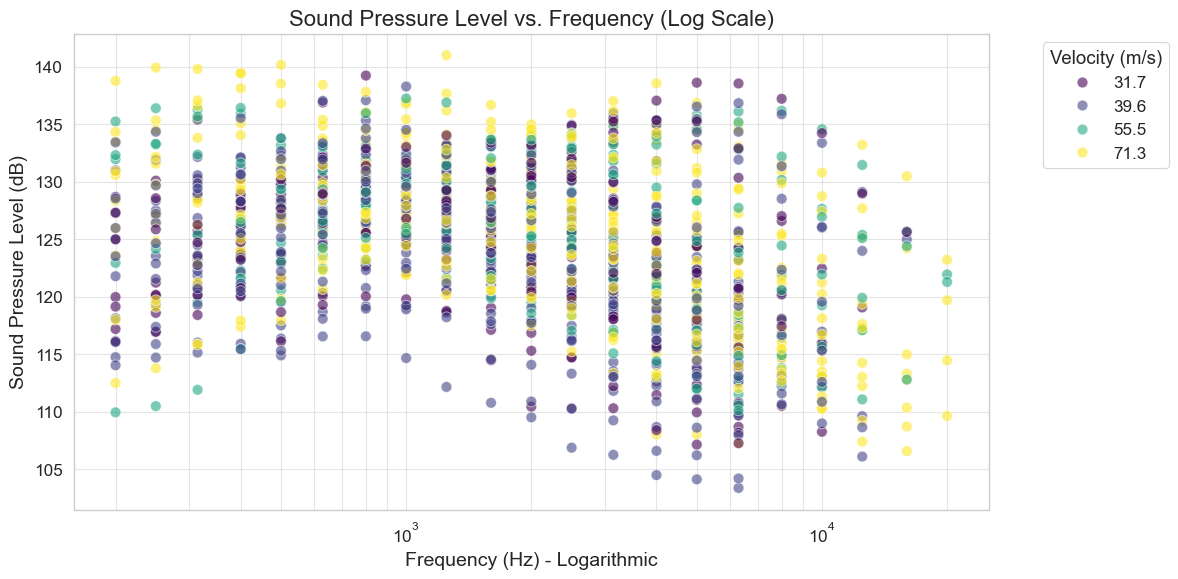


📝 **Scientific Insight:** - Sound pressure levels peak at low frequencies (200-1000 Hz).
- A linear decay is observed towards higher frequencies on the logarithmic axis.
- Additionally, higher velocities (yellow points) shift the overall noise floor upwards.



In [4]:
plt.figure(figsize=(12, 6))

# Frequency axis should be logarithmic
sns.scatterplot(data=df, x='Frequency', y='Sound_Pressure_Level', 
                hue='Free_Stream_Velocity', palette='viridis', alpha=0.6, s=60)

plt.xscale('log') # Critical detail for acoustics
plt.title("Sound Pressure Level vs. Frequency (Log Scale)")
plt.xlabel("Frequency (Hz) - Logarithmic")
plt.ylabel("Sound Pressure Level (dB)")
plt.legend(title='Velocity (m/s)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

print("""
📝 **Scientific Insight:** - Sound pressure levels peak at low frequencies (200-1000 Hz).
- A linear decay is observed towards higher frequencies on the logarithmic axis.
- Additionally, higher velocities (yellow points) shift the overall noise floor upwards.
""")

/var/folders/98/t973kl4s23l931r_t6tztnsc0000gn/T/ipykernel_46156/1728543082.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Angle_of_Attack', y='Sound_Pressure_Level', palette='coolwarm')


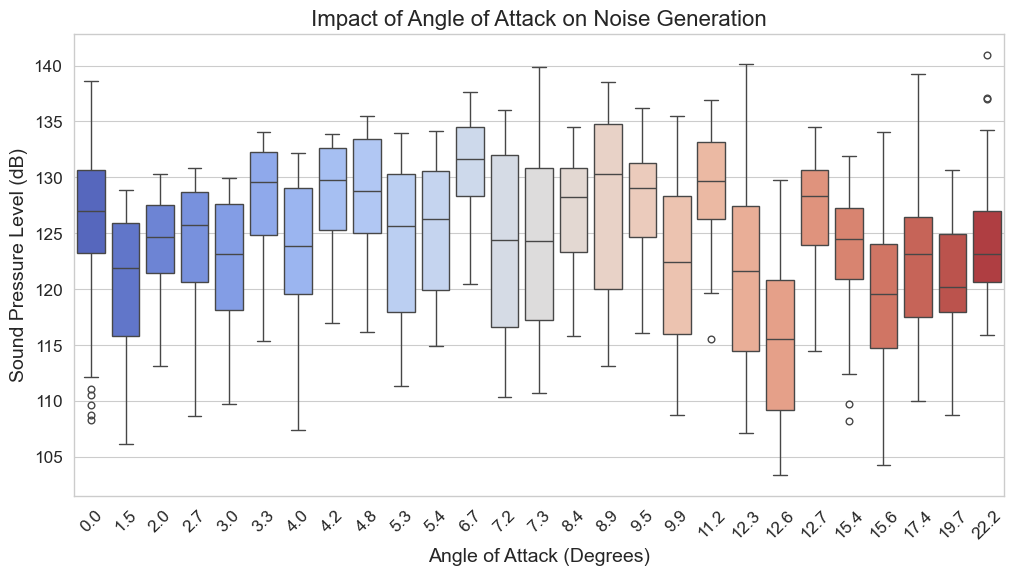


📝 **Engineering Comment:** - At 0 degrees (near laminar flow), the median noise is low.
- As the angle increases (especially after 10 degrees), flow separation and stall conditions likely begin, causing increased variance in noise levels.
- This behavior confirms the non-linear nature of the problem.



In [6]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='Angle_of_Attack', y='Sound_Pressure_Level', palette='coolwarm')

plt.title("Impact of Angle of Attack on Noise Generation")
plt.xlabel("Angle of Attack (Degrees)")
plt.ylabel("Sound Pressure Level (dB)")
plt.xticks(rotation=45)
plt.show()

print("""
📝 **Engineering Comment:** - At 0 degrees (near laminar flow), the median noise is low.
- As the angle increases (especially after 10 degrees), flow separation and stall conditions likely begin, causing increased variance in noise levels.
- This behavior confirms the non-linear nature of the problem.
""")